# Guided Risk Exploration — Diabetes Risk Prediction Panel
_Clinical gradients, lifestyle composition, guideline-threshold checks, and RF drivers across a 15,000-patient synthetic screening panel_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [mansiaggarwal88/diabetes-risk-prediction](https://www.kaggle.com/datasets/mansiaggarwal88/diabetes-risk-prediction)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***

# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Distributions](#Univariate)** <br>
**4. [Clinical Gradient by Risk Tier](#Clinical)** <br>
**5. [Lifestyle × Risk Composition](#Lifestyle)** <br>
**6. [Correlations and Threshold Check](#Thresholds)** <br>
**7. [RF Classification](#Classification)** <br>
**8. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
This is a **synthetic** 15,000-patient diabetes screening panel set across 18 Indian cities (a `generate_dataset.py` script ships inside the dataset archive). Each row carries demographics, clinical measurements (BMI, fasting blood sugar, HbA1c, blood pressure, waist circumference), lifestyle answers (activity, diet, smoking, alcohol, sleep, stress), and an assigned ordered target: `diabetes_risk` ∈ **Low → Moderate → High** (60% / 25% / 15%).

Because the labels come from a generator, associations here are properties of its rules — the exploration's job is to *reverse-engineer which inputs the generator actually used* and to check whether the assigned tiers respect real clinical guideline thresholds (HbA1c 5.7 / 6.5, fasting glucose 100 / 126). Useful as a classification and stratification drill, not as epidemiology.

# **2. Setup and Data Peek:** <a id="Setup"></a>

In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

import kagglehub

# Set Plot Theme (same family as the guided series)
sns.set_theme(style="whitegrid")
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)

/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
Three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics. The sklearn stack (`RandomForestClassifier` in a `ColumnTransformer`/`OneHotEncoder` pipeline, confusion matrix) supports the closing classification drill — an exploratory probe of which features the risk generator leaned on, not a clinical model. `kagglehub` resolves the CSV both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the other guided notebooks so sequential plots feel like one continuous exploration.

In [2]:
# Read and Peak at Data
CSV_BASENAME = "diabetes_risk.csv"
KAGGLE_SLUG = "mansiaggarwal88/diabetes-risk-prediction"
RISK_ORDER = ["Low", "Moderate", "High"]
CLINICAL_COLS = [
    "bmi", "fasting_blood_sugar", "hba1c_level",
    "blood_pressure_systolic", "blood_pressure_diastolic", "waist_circumference_cm",
]
LIFESTYLE_COLS = [
    "family_history_diabetes", "physical_activity_level", "diet_type",
    "smoking_status", "alcohol_consumption",
]
UNKNOWN_FILL_COLS = ["smoking_status", "alcohol_consumption", "income_bracket"]


def resolve_csv_path(basename: str = CSV_BASENAME) -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(basename):
            return p
    local_data = Path("data") / basename
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / basename
    if not p.exists():
        hits = list(root.rglob(basename))
        assert hits, f"expected {basename} under {root}"
        p = hits[0]
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)
df = pd.read_csv(csv_path)
assert df.shape == (15000, 19), df.shape
assert df["patient_id"].is_unique
assert set(df["diabetes_risk"].unique()) == set(RISK_ORDER)

# Missing lifestyle answers are informative non-response → explicit 'Unknown' level, no imputation
print("Nulls before Unknown fill:")
print(df.isnull().sum()[df.isnull().sum() > 0].to_string())
for c in UNKNOWN_FILL_COLS:
    df[c] = df[c].fillna("Unknown")
assert df.isnull().sum().sum() == 0

df["diabetes_risk"] = pd.Categorical(df["diabetes_risk"], categories=RISK_ORDER, ordered=True)
df["risk_ord"] = df["diabetes_risk"].cat.codes  # 0 / 1 / 2 for rank correlations

print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Risk tier counts:", df["diabetes_risk"].value_counts().to_dict())
print("Cities:", df["city"].nunique())
display(df.sample(5, random_state=7))

Nulls before Unknown fill:
smoking_status          472
alcohol_consumption    3788
income_bracket          463
Dataframe Dimension: 15000 Rows, 20 Columns
Risk tier counts: {'Low': 9000, 'Moderate': 3750, 'High': 2250}
Cities: 18


,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk,risk_ord
404,405,47,Male,Lucknow,24.2,No,Sedentary,Non-Vegetarian,Current,Never,7.1,5,192,7.6,140,90,108.2,Middle,Moderate,1
5221,5222,53,Male,Mumbai,22.0,No,Active,Non-Vegetarian,Unknown,Occasional,7.0,5,266,9.0,142,90,101.8,Middle,High,2
3357,3358,32,Male,Bengaluru,28.7,Yes,Sedentary,Non-Vegetarian,Never,Occasional,9.0,6,199,7.5,148,90,115.1,Middle,Moderate,1
7336,7337,41,Female,Bengaluru,25.1,Yes,Moderate,Non-Vegetarian,Never,Occasional,7.0,8,190,6.5,160,90,104.6,Middle,Low,0
8313,8314,53,Female,Lucknow,22.9,No,Active,Vegetarian,Never,Never,7.0,8,181,6.8,136,90,96.0,Low,Low,0


**Code Explanation and Reasoning:** <br>
`resolve_csv_path` keeps the notebook runnable in both worlds: on Kaggle it walks `/kaggle/input`, locally it falls back to `kagglehub.dataset_download`.

The one data decision made at load time: `smoking_status` (472 nulls), `alcohol_consumption` (3,788 — a quarter of respondents), and `income_bracket` (463) get an explicit **"Unknown"** level instead of imputation or row-dropping. Non-response on smoking/alcohol questions is plausibly informative in its own right, and this keeps all 15,000 rows in every analysis. `diabetes_risk` becomes an *ordered* categorical with a numeric shadow (`risk_ord`) so rank correlations can treat the tiers as a gradient.

In [3]:
unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]).sort_values("Unique", ascending=False))
df[CLINICAL_COLS + ["age", "hours_sleep_per_night", "stress_level"]].describe().round(2)

,Column,Unique,Null
0,patient_id,15000,0
16,waist_circumference_cm,614,0
12,fasting_blood_sugar,273,0
4,bmi,239,0
14,blood_pressure_systolic,89,0
10,hours_sleep_per_night,73,0
13,hba1c_level,71,0
1,age,58,0
15,blood_pressure_diastolic,58,0
3,city,18,0


,bmi,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,age,hours_sleep_per_night,stress_level
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,23.06,168.79,6.88,139.50,86.26,100.21,44.33,7.31,5.94
std,4.05,38.37,0.84,12.66,8.39,10.76,10.38,1.11,2.15
min,15.00,72.00,4.80,80.00,50.00,73.20,18.00,3.00,1.00
25%,20.10,145.00,6.30,130.00,80.00,92.50,38.00,6.70,4.00
50%,22.70,165.00,6.80,140.00,88.00,99.30,45.00,7.00,6.00
75%,25.60,189.00,7.30,150.00,90.00,106.90,52.00,8.00,7.00
max,40.80,400.00,13.40,200.00,120.00,148.20,80.00,12.00,10.00


**Interpretation** <br>
Clean panel: 15,000 unique patients, zero remaining nulls after the Unknown fill. The clinical ranges immediately flag this as a **screening-skewed generator**: mean fasting blood sugar sits well above 120 mg/dL and mean HbA1c near 6.5% — far above general-population norms, so most simulated patients are already in pre-diabetic/diabetic territory by guideline standards even in the "Low" tier. Keep that in mind when reading the threshold crosstabs in section 6.

# **3. Univariate Distributions:** <a id="Univariate"></a>

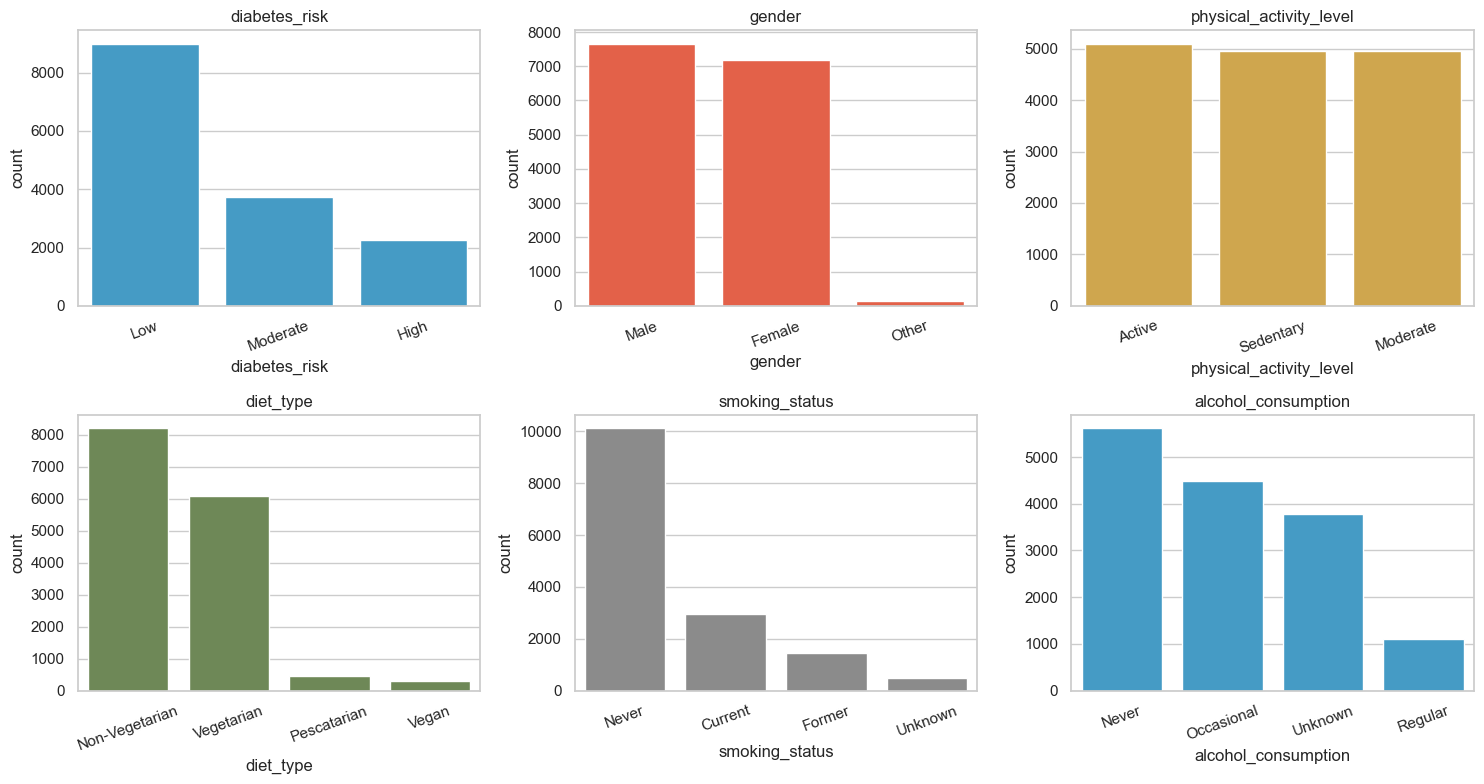

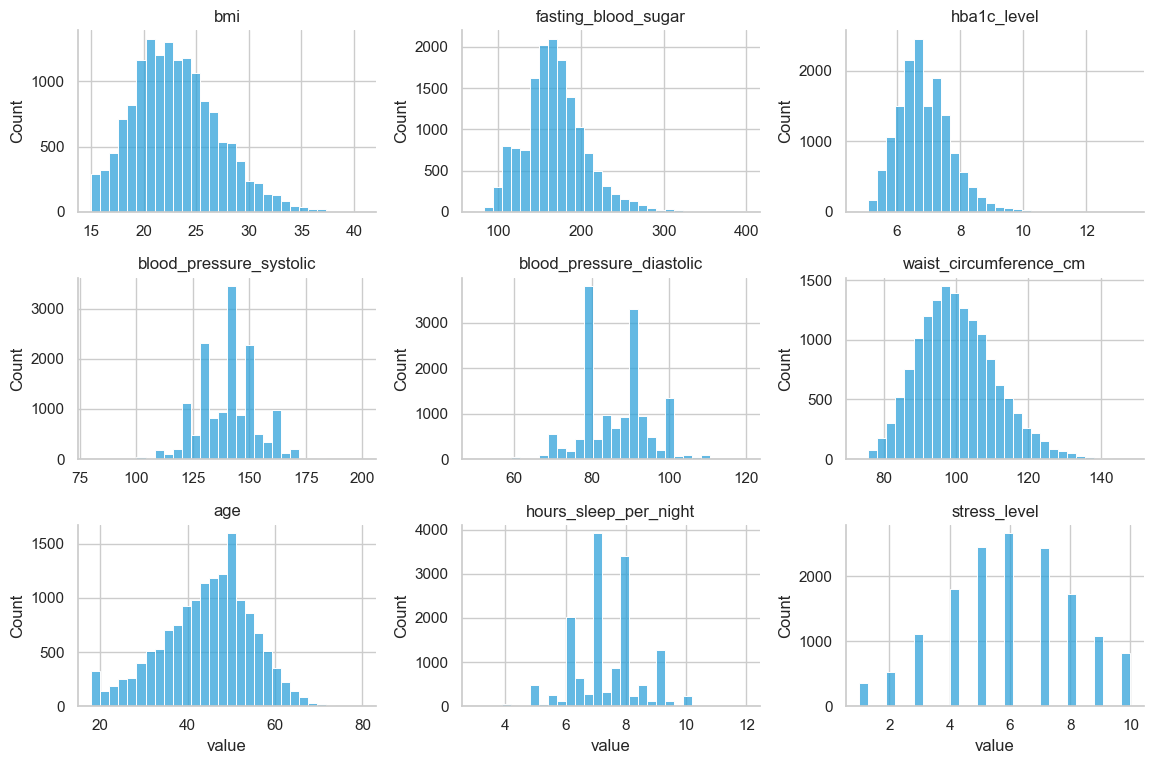

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, col, color in [
    (axes[0], "diabetes_risk", "#30a2da"),
    (axes[1], "gender", "#fc4f30"),
    (axes[2], "physical_activity_level", "#e5ae38"),
    (axes[3], "diet_type", "#6d904f"),
    (axes[4], "smoking_status", "#8b8b8b"),
    (axes[5], "alcohol_consumption", "#30a2da"),
]:
    order = df[col].value_counts().index if col != "diabetes_risk" else RISK_ORDER
    sns.countplot(data=df, x=col, order=order, ax=ax, color=color)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

num_panel = CLINICAL_COLS + ["age", "hours_sleep_per_night", "stress_level"]
melt = df[num_panel].melt(var_name="feature", value_name="value")
g = sns.FacetGrid(melt, col="feature", col_wrap=3, sharex=False, sharey=False, height=2.6, aspect=1.5)
g.map_dataframe(sns.histplot, x="value", bins=30, color="#30a2da")
g.set_titles("{col_name}")
plt.show()

**Interpretation** <br>
The target is imbalanced by design (60/25/15), which sets the baseline for the classifier later: always predicting "Low" already scores 60%. Lifestyle marginals look survey-like — non-vegetarian and vegetarian dominate diet, never-smokers dominate smoking, and the Unknown bar on alcohol is large enough to be its own segment. The clinical histograms are smooth and unimodal with generator-typical clipping at the edges; nothing bimodal, which hints the risk tiers were drawn from thresholds/scores on these variables rather than from separate populations.

# **4. Clinical Gradient by Risk Tier:** <a id="Clinical"></a>

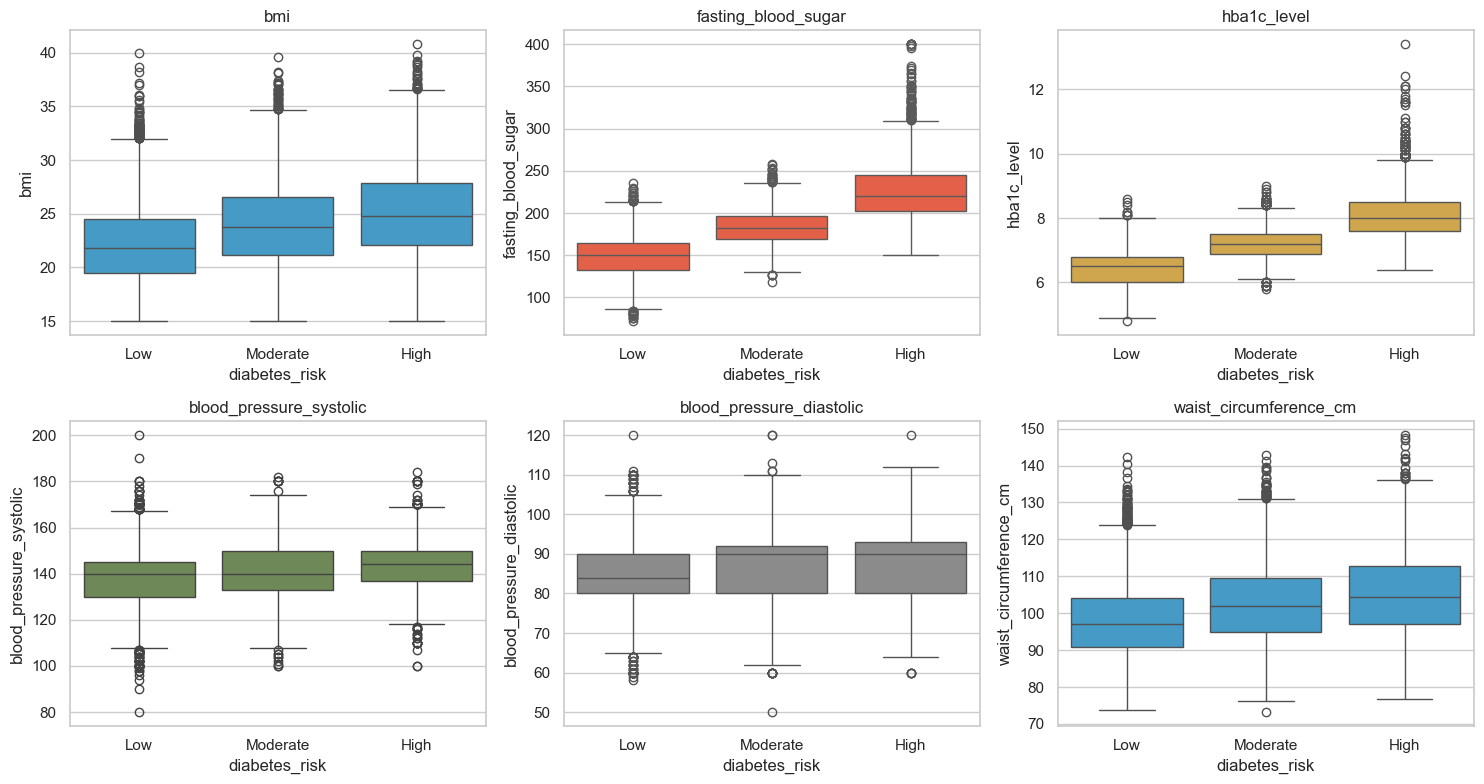

,bmi,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,age,hours_sleep_per_night,stress_level
diabetes_risk,,,,,,,,,
Low,21.8,150.0,6.5,140.0,84.0,97.2,43.0,7.0,6.0
Moderate,23.8,182.0,7.2,140.0,90.0,102.0,48.0,7.0,6.0
High,24.8,220.0,8.0,144.0,90.0,104.5,50.0,7.0,6.0


,feature,spearman_rho_vs_risk,p_value
0,fasting_blood_sugar,0.732,0.000000e+00
1,hba1c_level,0.720,0.000000e+00
2,age,0.298,2.946807e-304
3,bmi,0.282,3.512458e-272
4,waist_circumference_cm,0.260,1.222086e-230
5,blood_pressure_systolic,0.215,1.408379e-156
6,blood_pressure_diastolic,0.168,3.643892e-95
7,stress_level,0.103,1.071571e-36
8,hours_sleep_per_night,-0.045,3.633494e-08


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
colors = ["#30a2da", "#fc4f30", "#e5ae38", "#6d904f", "#8b8b8b", "#30a2da"]
for ax, col, color in zip(axes, CLINICAL_COLS, colors):
    sns.boxplot(data=df, x="diabetes_risk", y=col, order=RISK_ORDER, ax=ax, color=color)
    ax.set_title(col)
plt.tight_layout()
plt.show()

med = df.groupby("diabetes_risk", observed=True)[
    CLINICAL_COLS + ["age", "hours_sleep_per_night", "stress_level"]
].median()
display(med.round(2))

# Rank correlation of each numeric with the ordered tier
rows = []
for c in CLINICAL_COLS + ["age", "hours_sleep_per_night", "stress_level"]:
    rho, p = stats.spearmanr(df[c], df["risk_ord"])
    rows.append({"feature": c, "spearman_rho_vs_risk": round(float(rho), 3), "p_value": float(p)})
display(pd.DataFrame(rows).sort_values("spearman_rho_vs_risk", key=abs, ascending=False).reset_index(drop=True))

**Interpretation** <br>
The gradient is steep exactly where a clinician would look: the **two lab values dominate** — fasting blood sugar (median 150 → 220 mg/dL across tiers, Spearman ρ ≈ 0.73) and HbA1c (6.5 → 8.0%, ρ ≈ 0.72) — while everything else contributes mildly: age, BMI, and waist circumference sit near ρ ≈ 0.26–0.30, blood pressure lower still, and sleep hours / stress barely register. So the generator behaves like a lab-led risk score with demographic and adiposity seasoning. The boxes still overlap between adjacent tiers even for the labs, which is why the classifier in section 7 will miss mostly on neighbors.

# **5. Lifestyle × Risk Composition:** <a id="Lifestyle"></a>

Overall risk shares (baseline): {'Low': 0.6, 'Moderate': 0.25, 'High': 0.15}


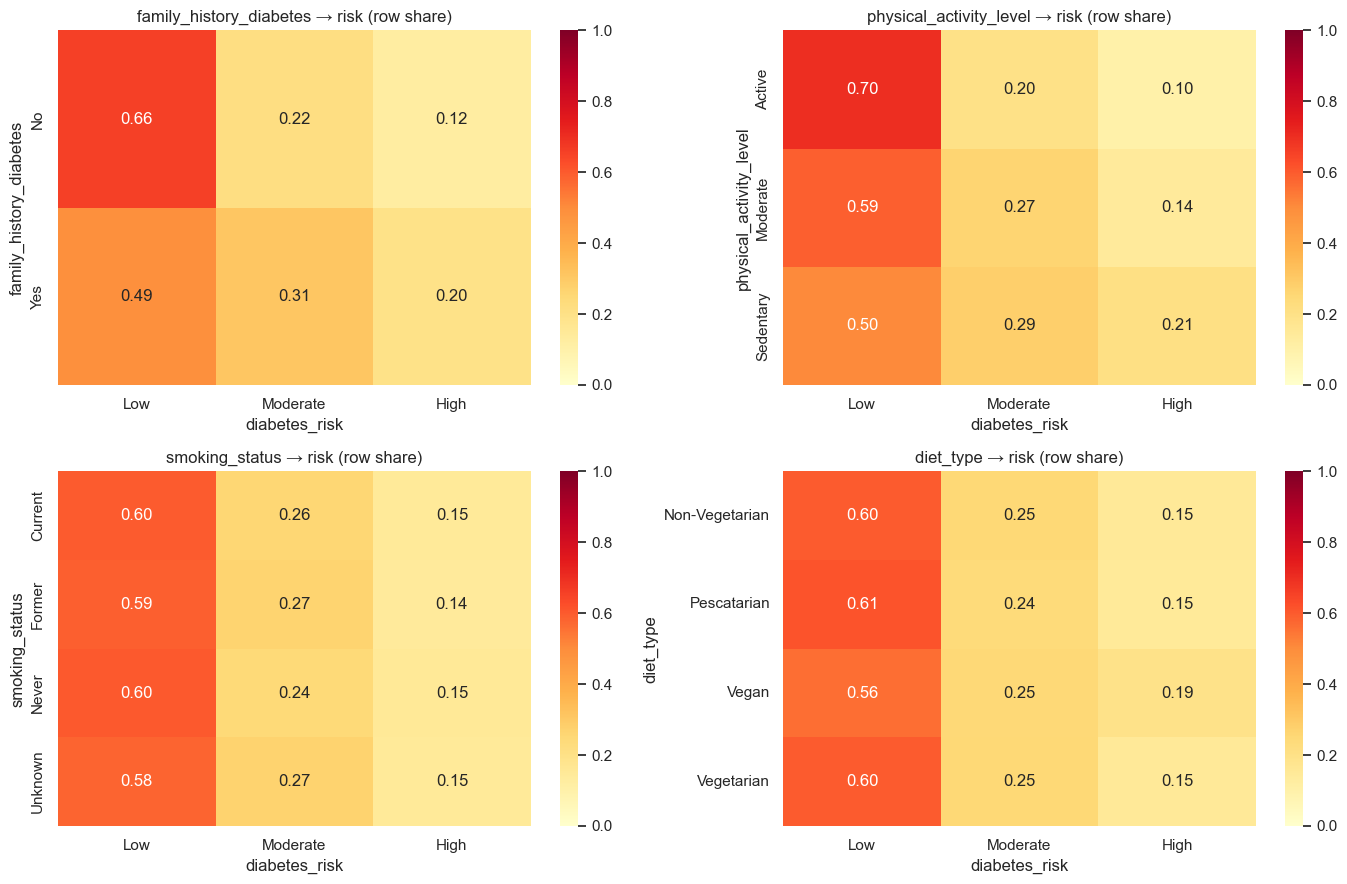

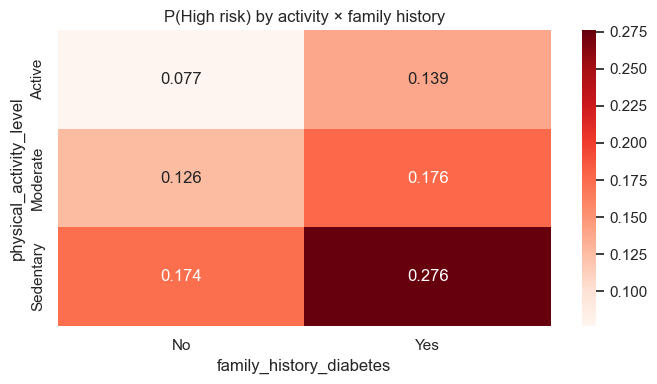

In [6]:
overall = df["diabetes_risk"].value_counts(normalize=True).reindex(RISK_ORDER)
print("Overall risk shares (baseline):", overall.round(3).to_dict())

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()
for ax, col in zip(axes, ["family_history_diabetes", "physical_activity_level", "smoking_status", "diet_type"]):
    ct = pd.crosstab(df[col], df["diabetes_risk"], normalize="index").reindex(columns=RISK_ORDER)
    sns.heatmap(ct, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1, ax=ax)
    ax.set_title(f"{col} → risk (row share)")
plt.tight_layout()
plt.show()

# High-risk rate by two lifestyle axes at once
df["is_high"] = (df["diabetes_risk"] == "High").astype(int)
pivot = df.pivot_table(index="physical_activity_level", columns="family_history_diabetes",
                       values="is_high", aggfunc="mean", observed=True)
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="Reds", ax=ax)
ax.set_title("P(High risk) by activity × family history")
plt.tight_layout()
plt.show()

**Interpretation** <br>
Read every heatmap row against the 0.60 / 0.25 / 0.15 baseline. **Physical activity and family history are the two levers that matter**: sedentary patients hit a 21% High share versus 10% for active ones, and a family history lifts High from 12.5% to nearly 20%. Smoking and diet rows are essentially flat copies of the baseline (the vegan bump rests on only ~290 patients), and the Unknown smoking row behaves like a blend rather than a distinct risk group — non-response wasn't wired into the generator. The two-axis pivot shows the real levers stack roughly additively: sedentary + family history reaches a 27.6% High rate, 3.6× the 7.7% of active + no-history.

# **6. Correlations and Threshold Check:** <a id="Thresholds"></a>

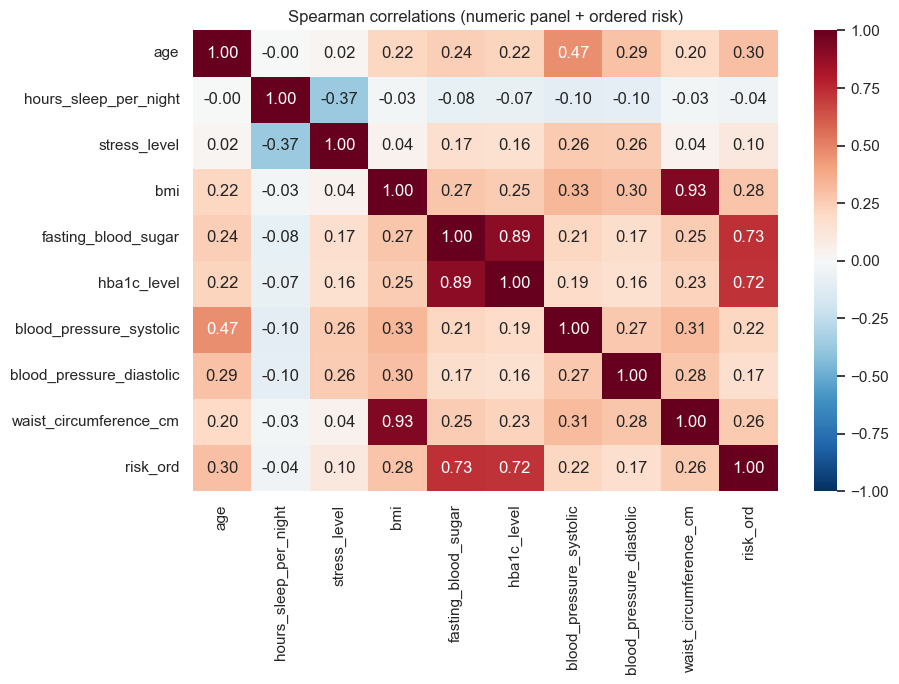

HbA1c band counts: {'Diabetic >=6.5': 10346, 'Prediabetic 5.7-6.4': 3881, 'Normal <5.7': 773}
Fasting sugar band counts: {'Diabetic >=126': 13092, 'Prediabetic 100-125': 1744, 'Normal <100': 164}


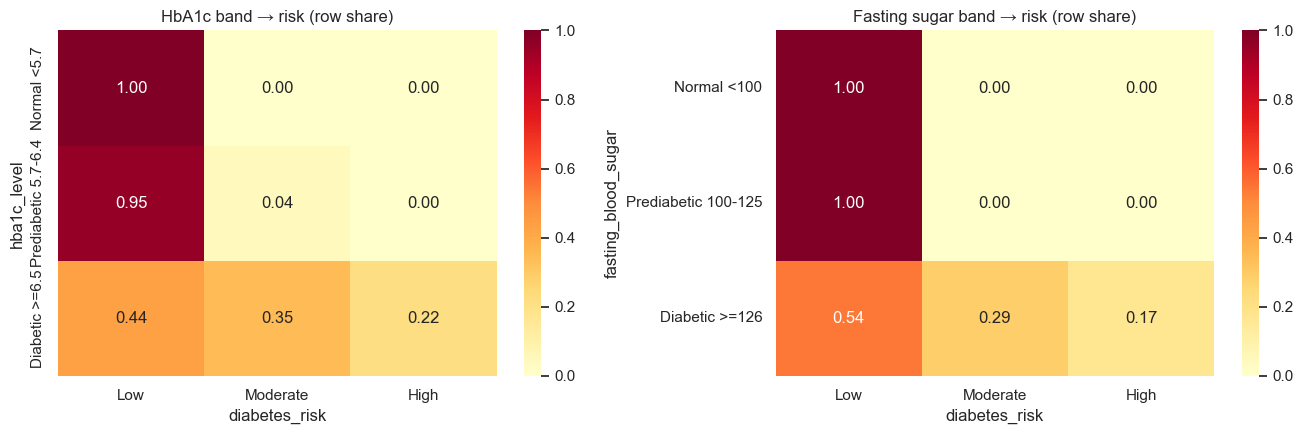

In [7]:
NUM_PANEL = ["age", "hours_sleep_per_night", "stress_level"] + CLINICAL_COLS + ["risk_ord"]
fig, ax = plt.subplots(figsize=(9.5, 7))
sns.heatmap(df[NUM_PANEL].corr(method="spearman"), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Spearman correlations (numeric panel + ordered risk)")
plt.tight_layout()
plt.show()

# Clinical guideline bands vs assigned tier — does the generator respect ADA thresholds?
hba1c_band = pd.cut(df["hba1c_level"], bins=[0, 5.7, 6.5, np.inf], right=False,
                    labels=["Normal <5.7", "Prediabetic 5.7-6.4", "Diabetic >=6.5"])
fbs_band = pd.cut(df["fasting_blood_sugar"], bins=[0, 100, 126, np.inf], right=False,
                  labels=["Normal <100", "Prediabetic 100-125", "Diabetic >=126"])
print("HbA1c band counts:", hba1c_band.value_counts().to_dict())
print("Fasting sugar band counts:", fbs_band.value_counts().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5))
for ax, band, name in [(axes[0], hba1c_band, "HbA1c band"), (axes[1], fbs_band, "Fasting sugar band")]:
    ct = pd.crosstab(band, df["diabetes_risk"], normalize="index").reindex(columns=RISK_ORDER)
    sns.heatmap(ct, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1, ax=ax)
    ax.set_title(f"{name} → risk (row share)")
plt.tight_layout()
plt.show()

**Interpretation** <br>
The correlation heatmap splits the numerics into an **adiposity block** (BMI ↔ waist circumference) and largely independent lab/pressure axes, with `risk_ord`'s row dominated by the two labs (ρ ≈ 0.72–0.73). The threshold crosstabs reveal the generator's gating logic: guideline thresholds act as a **necessary condition** — patients below the diabetic HbA1c band are almost never labeled above Low (the guideline-normal and prediabetic rows are ~95–100% Low) — but not a sufficient one, since even within the guideline-diabetic band only ~22% land in High. And with ~69% of the panel above the HbA1c 6.5 cutoff and 87% above fasting 126, the "Low" tier is full of patients a clinic would already flag: these labels grade *relative* risk inside a hyperglycemic population, not diagnoses.

# **7. RF Classification:** <a id="Classification"></a>

Hold-out accuracy: 0.799 vs majority-class baseline 0.600 (test n = 3750)


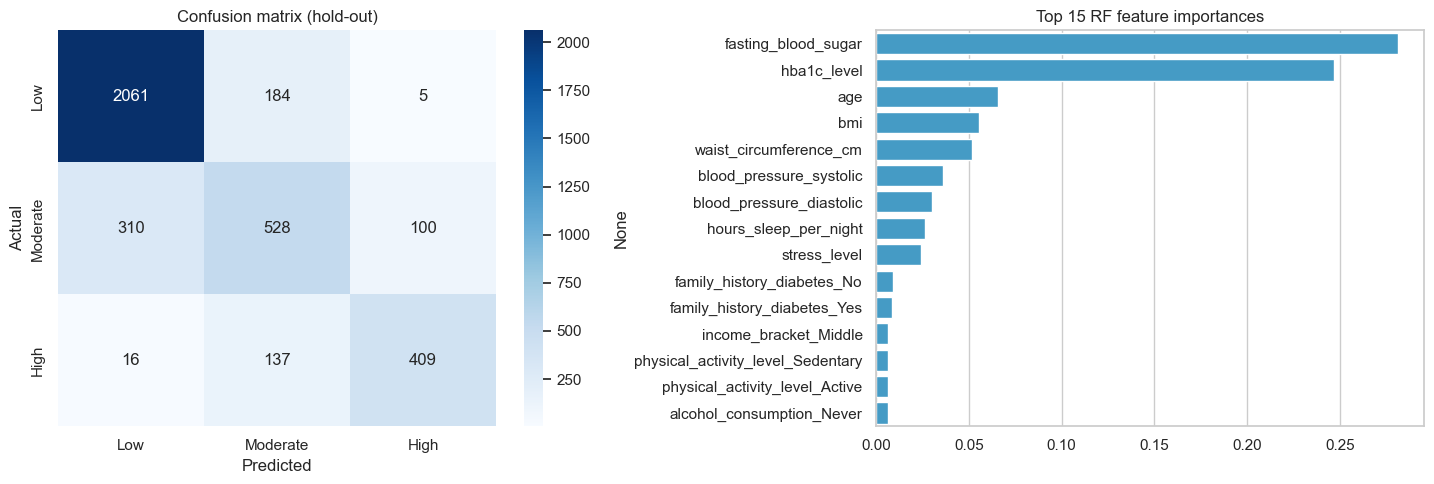

,importance
fasting_blood_sugar,0.2811
hba1c_level,0.2466
age,0.0658
bmi,0.0554
waist_circumference_cm,0.0516
blood_pressure_systolic,0.0361
blood_pressure_diastolic,0.0302
hours_sleep_per_night,0.0263
stress_level,0.0245
family_history_diabetes_No,0.0091


In [8]:
# RF probe of the generator's rules — which features actually drive the assigned tier?
FEATURE_NUM = CLINICAL_COLS + ["age", "hours_sleep_per_night", "stress_level"]
FEATURE_CAT = ["gender", "city", "family_history_diabetes", "physical_activity_level",
               "diet_type", "smoking_status", "alcohol_consumption", "income_bracket"]
X = df[FEATURE_NUM + FEATURE_CAT]
y = df["diabetes_risk"].astype(str)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7, stratify=y)

pre = ColumnTransformer([
    ("num", "passthrough", FEATURE_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURE_CAT),
])
pipe = Pipeline([
    ("pre", pre),
    ("rf", RandomForestClassifier(n_estimators=300, max_depth=14, random_state=7, n_jobs=-1)),
])
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
acc = accuracy_score(y_test, pred)
baseline = y_test.value_counts(normalize=True).max()
print(f"Hold-out accuracy: {acc:.3f} vs majority-class baseline {baseline:.3f} (test n = {len(y_test)})")

cm = confusion_matrix(y_test, pred, labels=RISK_ORDER)
rf = pipe.named_steps["rf"]
names = FEATURE_NUM + list(pipe.named_steps["pre"].named_transformers_["cat"].get_feature_names_out(FEATURE_CAT))
imp = pd.Series(rf.feature_importances_, index=names).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=RISK_ORDER, yticklabels=RISK_ORDER, ax=axes[0])
axes[0].set_title("Confusion matrix (hold-out)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
sns.barplot(x=imp.values, y=imp.index, ax=axes[1], color="#30a2da")
axes[1].set_title("Top 15 RF feature importances")
plt.tight_layout()
plt.show()
display(imp.round(4).rename("importance").to_frame())

**Interpretation** <br>
The forest reaches ~80% hold-out accuracy against the 60% majority baseline, and *how* it errs is as informative as the score: confusion concentrates in the **adjacent tiers** (Low↔Moderate, Moderate↔High) while direct Low↔High swaps are rare (a couple dozen out of 3,750) — exactly what an underlying continuous risk score sliced into three bins produces. The importance ranking is the generator autopsy: fasting blood sugar (≈ 0.28) and HbA1c (≈ 0.25) alone absorb over half the split value, age and the adiposity pair take the next tier, and every categorical — family history included — sits below 0.01; city, diet, and income dummies are noise. The ~20% error floor is the label noise the generator injected around its tier boundaries; no feature set recovers it.

# **8. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A synthetic 15,000-patient diabetes screening panel (18 Indian cities) with clinical, lifestyle, and demographic features and an ordered Low/Moderate/High risk label produced by a generator script.

**Working takeaways:** <br>
- The 60/25/15 tier imbalance sets a 60% majority baseline that any classifier must clear.
- Non-response in smoking/alcohol/income is kept as an explicit "Unknown" level (a quarter of alcohol answers) — no imputation, and the Unknown rows track the baseline.
- The label is a lab-led risk score: fasting blood sugar and HbA1c dominate (Spearman ρ ≈ 0.72–0.73, medians 150→220 mg/dL and 6.5→8.0% across tiers), with age/adiposity mild and sleep/stress negligible.
- Physical activity and family history are the lifestyle levers and stack roughly additively (sedentary + family history: 27.6% High vs 7.7% for active + no-history); diet and smoking are flat.
- Guideline cutoffs gate the tiers (below-threshold patients are almost never Moderate/High) but don't determine them — and ~69% of the panel exceeds the diabetic HbA1c cutoff, so "Low" is relative, not clinical.
- The RF probe lands at ~80% hold-out accuracy with errors confined to adjacent tiers; the two labs absorb over half the importance and all categoricals are marginal.

**Open follow-ups:** <br>
- Ordinal-aware modeling (cumulative-logit or ordered targets) to exploit the Low<Moderate<High structure.
- Permutation importances to de-bias the RF ranking against high-cardinality dummies like city.
- Read `generate_dataset.py` shipped with the archive and score the reverse-engineering above against the actual rules.
- Calibration curves per tier if the labels were ever to be used as screening probabilities.